(shooting-method-section)=
# The shooting method

Consider the two-point boundary value problem 

$$ y'' = f(t,y), \qquad t \in [t_0, t_{\max}], \qquad y(t_0) = a ,\qquad y(t_{\max}) = b. $$

To solve a second-order boundary value problem numerically, we first rewrite it as a system of first-order ODEs. This allows us to apply the initial value problem solvers developed in earlier chapters.

Let 

$$ \begin{align*}
    y_1' &= y_2 ,\\
    y_2' &= f(t, y_1, y_2).
\end{align*} $$

Then the boundary condition $y(t_0) = a$ gives $y_1(t_0) = a$, but the initial value $y_2(t_0) = y'(t_0)$ is unknown. The **shooting method** treats this missing value as an unknown parameter $s$. For a chosen value of $s$, we solve the resulting initial values problem and compare the computed value of $y_1(t_{\max})$ with the required boundary condition $b$. The value of $s$ is then adjusted until the boundary condition at $t = t_{\max}$ is satisfied.

The method is called the *shooting method* because it resembles aiming at a target. If the computed solution misses the required boundary value, the initial slope is adjusted and another "shot" is taken until the target is hit.

````{prf:example}
:label: shooting-example-1

Use the Euler method with a step length of $h = 0.2$ and the shooting method to solve the following boundary value problem

$$ \begin{align*}
    y'' - y' - y &= 0, & y(0) &= 0, & y(1) &= 2. 
\end{align*} $$

---

**Solution**

Rewriting this as a system of first-order ODEs gives

$$ \begin{align*}
    y_1' &= y_2, & y_1 (0) &= 0, &&\\
    y_2' &= y_1 +y_2, & y_2 (0) &= s, &&
\end{align*} $$

where $s$ is a guess of $y'(0)$.

The Euler method solutions using a guess value of $s = 1$ is tabulated below. 

|  $t$  |  $y_1$   |  $y_2$   |
|:-----:|:--------:|:--------:|
|  0.00 | 0.000000 | 1.000000 |
|  0.20 | 0.200000 | 1.200000 |
|  0.40 | 0.440000 | 1.480000 |
|  0.60 | 0.736000 | 1.864000 |
|  0.80 | 1.108800 | 2.384000 |
|  1.00 | 1.585600 | 3.082560 |

The numerical solution at the upper boundary is $y_1(1) = 1.585600$. Lets try again but with an increased guess value of $s = 2$.

|  $t$  |  $y_1$  |  $y_2$  |
|:-----:|:-------:|:-------:|
|  0.00 | 0.000000 | 2.000000 |
|  0.20 | 0.400000 | 2.400000 |
|  0.40 | 0.880000 | 2.960000 |
|  0.60 | 1.472000 | 3.728000 |
|  0.80 | 2.217600 | 4.768000 |
|  1.00 | 3.171200 | 6.165120 |

Here we have $y_1(1) = 3.171200$. Since the solution obtained with $s$ gives $y_1(1) < 2$ and the solution obtained with $s=2$ gives $y_1(1) > 2$, the correct value of $s$ must lie between 1 and 2. Since the desired initial slope lies between 1 and 2, a natural next choice is $s = 1.5$.

|  $t$  |  $y_1$  |  $y_2$  |
|:-----:|:-------:|:-------:|
|  0.00 | 0.000000 | 1.500000 |
|  0.20 | 0.300000 | 1.800000 |
|  0.40 | 0.660000 | 2.220000 |
|  0.60 | 1.104000 | 2.796000 |
|  0.80 | 1.663200 | 3.576000 |
|  1.00 | 2.378400 | 4.623840 |

The solutions using the three guess values of $s=1$, $s=2$ and $s=1.5$ are plotted below.


```{glue:figure} shooting_example_plot_1
:name: bvp-example-figure
:figwidth: 600

Solutions of the BVP $y'' - y' - y = 0$, $y(0) = 0$, $y(1) = 2$ using initial values for $y'(0) = s$ where $s = 1$, $s = 2$ and $s = 1.5$.
```

The approximation obtained using $s=1.5$ is closer to satisfying the boundary condition at $t=1$ than the previous guesses. In practice, the shooting method is usually combined with a root-finding algorithm such as the secant method to determine the value of $s$ automatically.

````


s = 1.00

|  $t$  |  $y_1$  |  $y_2$  |
|:-----:|:-------:|:-------:|
|  0.00 | 0.000000 | 1.000000 |
|  0.20 | 0.200000 | 1.200000 |
|  0.40 | 0.440000 | 1.480000 |
|  0.60 | 0.736000 | 1.864000 |
|  0.80 | 1.108800 | 2.384000 |
|  1.00 | 1.585600 | 3.082560 |

s = 2.00

|  $t$  |  $y_1$  |  $y_2$  |
|:-----:|:-------:|:-------:|
|  0.00 | 0.000000 | 2.000000 |
|  0.20 | 0.400000 | 2.400000 |
|  0.40 | 0.880000 | 2.960000 |
|  0.60 | 1.472000 | 3.728000 |
|  0.80 | 2.217600 | 4.768000 |
|  1.00 | 3.171200 | 6.165120 |

s = 1.50

|  $t$  |  $y_1$  |  $y_2$  |
|:-----:|:-------:|:-------:|
|  0.00 | 0.000000 | 2.000000 |
|  0.20 | 0.400000 | 2.400000 |
|  0.40 | 0.880000 | 2.960000 |
|  0.60 | 1.472000 | 3.728000 |
|  0.80 | 2.217600 | 4.768000 |
|  1.00 | 3.171200 | 6.165120 |


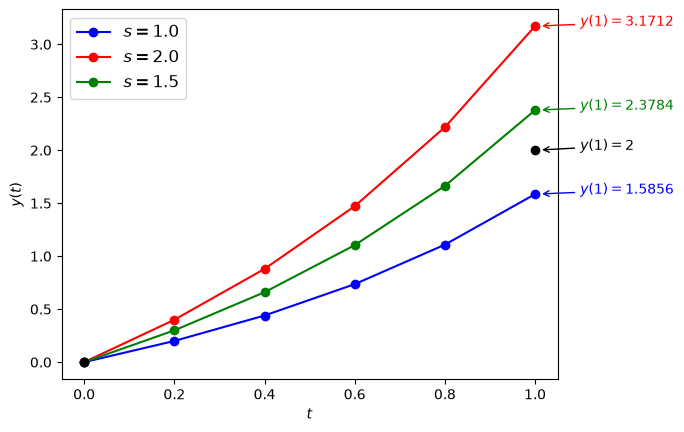

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def euler(f, tspan, y0, h):
    
    N = len(y0)
    nsteps = int((tspan[1] - tspan[0]) / h)
    t = np.zeros(nsteps + 1)
    y = np.zeros((N, nsteps + 1))
        
    t[0] = tspan[0]
    y[:,0] = y0
    
    for n in range(nsteps):
        y[:,n+1] = y[:,n] + h * f(t[n], y[:,n])
        t[n+1] = t[n] + h

    return t, y.T


# Define ODE function
def f(t, y):
    return np.array([y[1], y[0] + y[1]])


# Define BVP parameters
tspan = [0, 1]  # boundaries of the t domain
bvals = [0, 2]  # boundary values
h = 0.2         # step length
s = [1, 2, 1.5] # guess values

# Calculate the solution to the IVP for the different guess values
t, y1 = euler(f, tspan, [bvals[0], s[0]], h)
t, y2 = euler(f, tspan, [bvals[0], s[1]], h)
t, y3 = euler(f, tspan, [bvals[0], s[2]], h)

# Print table of solutions
print(f"\ns = {y1[0,1]:0.2f}\n")
print("|  $t$  |  $y_1$  |  $y_2$  |")
print("|:-----:|:-------:|:-------:|")
for n in range(len(t)):
    print(f"| {t[n]:5.2f} | {y1[n,0]:7.6f} | {y1[n,1]:7.6f} |")

print(f"\ns = {y2[0,1]:0.2f}\n")
print("|  $t$  |  $y_1$  |  $y_2$  |")
print("|:-----:|:-------:|:-------:|")
for n in range(len(t)):
    print(f"| {t[n]:5.2f} | {y2[n,0]:7.6f} | {y2[n,1]:7.6f} |")

print(f"\ns = {y3[0,1]:0.2f}\n")
print("|  $t$  |  $y_1$  |  $y_2$  |")
print("|:-----:|:-------:|:-------:|")
for n in range(len(t)):
    print(f"| {t[n]:5.2f} | {y2[n,0]:7.6f} | {y2[n,1]:7.6f} |")
        
    
# Plot solution
fig, ax = plt.subplots()
plt.plot(t, y1[:,0], "bo-", label="$s = 1.0$")
plt.plot(t, y2[:,0], "ro-", label="$s = 2.0$")
plt.plot(t, y3[:,0], "go-", label="$s = 1.5$")
plt.plot(tspan, bvals, "ko")
plt.annotate(f"$y(1)={bvals[1]}$", xy=(tspan[1], bvals[1]), xytext=(tspan[1]+0.1, bvals[1]), arrowprops=dict(arrowstyle='->', shrinkB=5))
plt.annotate(f"$y(1)={y1[-1,0]}$", xy=(tspan[1], y1[-1,0]), xytext=(tspan[1]+0.1, y1[-1,0]), color="b", arrowprops=dict(arrowstyle='->', shrinkB=5, ec="b"))
plt.annotate(f"$y(1)={y2[-1,0]}$", xy=(tspan[1], y2[-1,0]), xytext=(tspan[1]+0.1, y2[-1,0]), color="r", arrowprops=dict(arrowstyle='->', shrinkB=5, ec="r"))
plt.annotate(f"$y(1)={y3[-1,0]:0.4f}$", xy=(tspan[1], y3[-1,0]), xytext=(tspan[1]+0.1, y3[-1,0]), color="g", arrowprops=dict(arrowstyle='->', shrinkB=5, ec="g"))
plt.xlabel("$t$")
plt.ylabel("$y(t)$")
plt.legend(fontsize=12)
plt.show()


from myst_nb import glue
glue("shooting_example_plot_1", fig, display=False)

(secant-method-section)=

## Improving the guess value using the secant method

In {prf:ref}`shooting-example-1`, successive guesses for the unknown initial slope produced numerical solutions that moved closer to the required boundary value at $t = t_{\max}$. One approach would be to repeatedly halve the interval containing the correct value of $s$, a strategy known as the *bisection method*. A more efficient alternative is the **secant method** which uses previous approximations to predict and improved value of $s$. 

The goal of the shooting method is to determine the value of $s = y'(t_0)$ that satisfies the boundary condition

$$ y(t_{\max}) = b. $$

Define the residual function

$$ g(s) = b - y(t_{\max}, s), $$

where $y(t_{\max}, s)$ denotes the numerical solution obtained using the initial slope $s$. 

If $g(s) = 0$, then the computed solution satisfies the boundary condition exact. Therefore, solving the boundary value problem reduces to finding the root of $g(s)$. 

The secant method generates a series of approximations

$$s_0, \; s_1, \; s_2, \; \ldots $$

that converge to a root of $g(s) = 0$. Given two previous approximations $s_{n - 1}$ and $s_{n - 2}$, the next approximation is computed using

$$ s_{n+1} = s_n - g(s_n)\frac{s_n - s_{n-1}}{g(s_n) - g(s_{n-1})}. $$(secant-method-equation)

The iteration continues until successive approximations differ by less than a prescribed tolerance, that is,

$$ |s_n - s_{n-1}| < tol. $$

````{prf:example}
:label: secant-method-example

Use the secant method to calculate the next guess value $s$ for the solution of the boundary value problem {prf:ref}`shooting-example-1` and calculate the solution to the BVP using this guess value.

---

**Solution**

From {prf:ref}`shooting-example-1` we have solutions at the upper boundary of 

$$ \begin{align*}
    y_1(1) &= 3.1712, & s_1 &= 2, \\
    y_1(1) &= 2.3784, & s_2 &= 1.5.
\end{align*} $$

The values of $g(s_1)$ and $g(s_2)$ are

$$ \begin{align*}
    g(s_1) &= 2 - 3.1712 = -1.1712, \\
    g(s_2) &= 2 - 2.3784 = -0.3784, 
\end{align*} $$

therefore, using equation {eq}`secant-method-equation` the next guess value calculated using the secant method is

$$ \begin{align*}
    s_3 &= s_2 - g(s_2) \left( \frac{s_2 - s_1}{g(s_2) - g(s_1)} \right) \\
    &= 1.5 - (-0.3784) \left( \frac{1.5 - 2}{-0.3784 - (-1.1712)} \right) = 1.2614. 
\end{align*} $$

The solution using a guess value of $s_3 = 1.2614$ are tabulated below.

|  $t$ | $y_1$  | $y_2$  |
|:----:|:------:|:------:|
| 0.00 | 0.0000 | 1.2614 |
| 0.20 | 0.2523 | 1.5136 |
| 0.40 | 0.5550 | 1.8668 |
| 0.60 | 0.9284 | 2.3512 |
| 0.80 | 1.3986 | 3.0071 |
| 1.00 | 2.0000 | 3.8882 |

Here the solution at the upper boundary is $y(t_{\max}) = 2$ which agrees to the required boundary condition $y(1) = 2$ correct to 4 decimal places.

```{glue:figure} shooting_example_plot_2
:name: bvp-example-figure-2
:figwidth: 600

Solution of the BVP $y'' - y' - y = 0$, $y(0) = 0$, $y(1) = 2$ using the shooting method.
```

````


## Code 

The code below defines a function called `shooting_method()` that calculates the solution to a boundary value problem using the shooting method.

`````{tab-set}
````{tab-item} Python
```python
def shooting_method(f, tspan, bvals, h, solver, tol=1e-8, maxiter=100):
    s0 = 1
    s1 = s0 + 1
    [t, y] = solver(f, tspan, [bvals[0], s0], h)
    g0 = bvals[1] - y[-1,0]

    for _ in range(maxiter):
        [t, y] = solver(f, tspan, [bvals[0], s1], h)
        g1 = bvals[1] - y[-1,0]
        s2 = s1 - g1 * (s1 - s0) / (g1 - g0)

        if abs(s2 - s1) < tol:
            return [t, y]

        s0 = s1
        g0 = g1
        s1 = s2
```
````

````{tab-item} MATLAB
```matlab
function [t, y] = shooting_method(f, tspan, bvals, h, solver)

s0 = 1;
s1 = s0 + 1;
[t, y] = solver(f, tspan, [bvals(1), s0], h);
g0 = bvals(2) - y(end, 1);

for i = 1 : 10
    [t, y] = solver(f, tspan, [bvals(1), s1], h);
    g1 = bvals(2) - y(end, 1);
    s2 = s1 - g1 * (s1 - s0) / (g1 - g0);

    if abs(s2 - s1) < 1e-8
        return
    end

    s0 = s1;
    g0 = g1;
    s1 = s2;
end

end
```
````
`````

The inputs to the function are

- `f` - the name of the ODE function
- `tspan` - an array of two values defining the boundaries of the $t$ domain
- `bvals` - an array of two values defining the upper and lower boundary values
- `h` - the step length used in the `solver` function
- `solver` - the name of the solver function, e.g., `euler`, `rk4` etc. (this needs to be defined elsewhere)

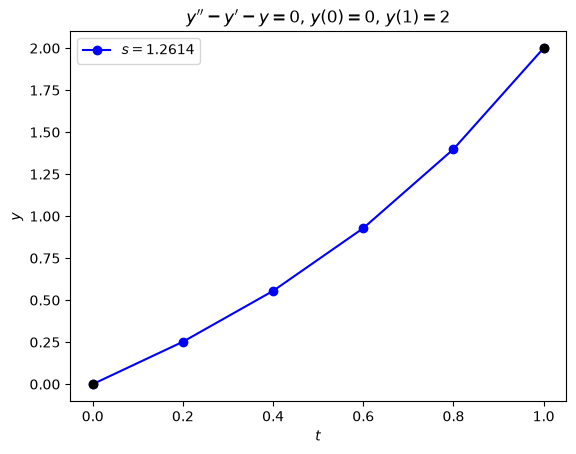

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define shooting method function
def shooting_method(f, tspan, bvals, h, solver):
    s0 = 1
    s1 = s0 + 1
    [t, y] = solver(f, tspan, [bvals[0], s0], h)
    g0 = bvals[1] - y[-1,0]

    for _ in range(10):
        [t, y] = solver(f, tspan, [bvals[0], s1], h)
        g1 = bvals[1] - y[-1,0]
        s2 = s1 - g1 * (s1 - s0) / (g1 - g0)

        if abs(s2 - s1) < 1e-8:
            return [t, y]

        s0 = s1
        g0 = g1
        s1 = s2


# Define ODE function
def f(t, y):
    return np.array([y[1], y[0] + y[1]])


# Define BVP parameters
tspan = [0, 1]  # boundaries of the t domain
bvals = [0, 2]  # boundary values
h = 0.2         # step length

# Solve BVP using the shooting method
[t, y] = shooting_method(f, tspan, bvals, h, euler)

# Plot solution
fig, ax = plt.subplots()
plt.plot(t, y[:,0], "bo-", label=f"$s = {y[0,1]:0.4f}$")
plt.plot(tspan, bvals, "ko")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title("$y'' - y' - y = 0$, $y(0) = 0$, $y(1) = 2$")
plt.legend()
plt.show()

from myst_nb import glue
glue("shooting_example_plot_2", fig, display=False)

## A note about accuracy

In {prf:ref}`secant-method-example` we iterated the Secant method until convergence and got a very accurate solution for the value of $y(b)$. We must be careful not to forget that this solution was obtained using the Euler method which being only first-order so expect it to be relatively inaccurate for the other values in the domain. 

The exact solution to the boundary value problem used here is

$$ \begin{align*}
    y = \frac{2e^{(1 - \sqrt{5})(t - 1)/2} (e^{\sqrt{5}t} - 1)}{e^{\sqrt{5}} - 1}.
\end{align*} $$

and the solutions using the Euler method and the RK4 method have been tabulated below and plotted in {numref}`bvp-euler-rk4-figure`.

| $t$  |  Euler   |   RK4    |  Exact   | Euler error | RK4 error |
|:----:|:--------:|:--------:|:--------:|:-----------:|:---------:|
| 0.00 | 0.000000 | 0.000000 | 0.000000 |   0.00e+00  | 0.00e+00  |
| 0.20 | 0.252270 | 0.221310 | 0.221296 |   3.10e-02  | 1.41e-05  |
| 0.40 | 0.554995 | 0.501444 | 0.501419 |   5.36e-02  | 2.50e-05  |
| 0.60 | 0.928355 | 0.865870 | 0.865840 |   6.25e-02  | 3.00e-05  |
| 0.80 | 1.398587 | 1.349436 | 1.349412 |   4.92e-02  | 2.42e-05  |
| 1.00 | 2.000000 | 2.000000 | 2.000000 |   0.00e+00  | 4.44e-16  |

```{glue:figure} bvp_euler_rk4_plot
:name: bvp-euler-rk4-figure
:figwidth: 600

Solutions to the boundary value problem $y'' - y' - y = 0$, $t \in [0,1]$, $y(0) = 0$, $y(1) = 2$ using the Euler and RK4 methods with $h=0.2$.
```

So despite the Secant method giving a guess value that gives an accurate solution at the upper boundary, the use of the Euler method does not give an accurate solution across the domain. The solution using the second-order Runge-Kutta method in comparison gives much more accurate solutions over the domain.

| $t$  |  Euler   |   RK4    |  Exact   | Euler error | RK4 error |
|:----:|:--------:|:--------:|:--------:|:-----------:|:---------:|
| 0.00 | 0.000000 | 0.000000 | 0.000000 |   0.00e+00  | 0.00e+00  |
| 0.20 | 0.252270 | 0.221310 | 0.221296 |   3.10e-02  | 1.41e-05  |
| 0.40 | 0.554995 | 0.501444 | 0.501419 |   5.36e-02  | 2.50e-05  |
| 0.60 | 0.928355 | 0.865870 | 0.865840 |   6.25e-02  | 3.00e-05  |
| 0.80 | 1.398587 | 1.349436 | 1.349412 |   4.92e-02  | 2.42e-05  |
| 1.00 | 2.000000 | 2.000000 | 2.000000 |   0.00e+00  | 0.00e+00  |


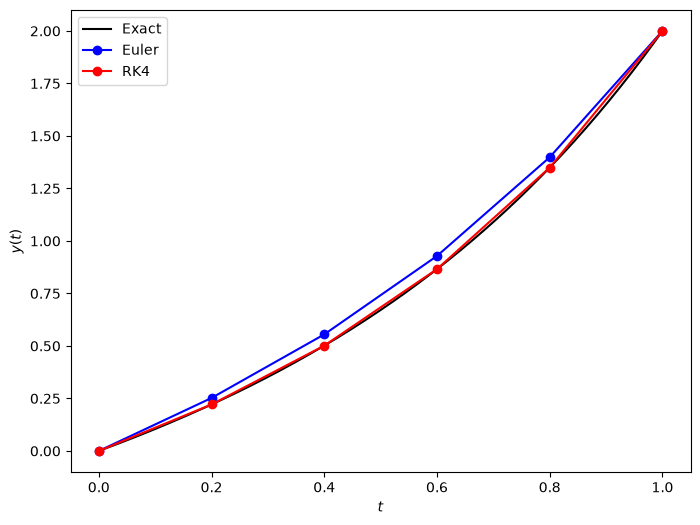

In [3]:
def rk4(f, tspan, y0, h):

    # Determine the number of ODEs in the system
    N = len(y0)

    # Calculate the number of steps required
    nsteps = int((tspan[1] - tspan[0]) / h)

    # Define solution arrays and assign initial values
    t = np.zeros(nsteps + 1)
    y = np.zeros((nsteps + 1, N))
    t[0] = tspan[0]
    y[0,:] = y0
    
    # Loop through the stages
    for n in range(nsteps):

        # Compute the stage values
        k1 = f(t[n], y[n,:])
        k2 = f(t[n] + 0.5 * h, y[n,:] + 0.5 * h * k1)
        k3 = f(t[n] + 0.5 * h, y[n,:] + 0.5 * h * k2)
        k4 = f(t[n] + h, y[n,:] + h * k3)

        # Compute the solution for the next step
        y[n+1,:] = y[n,:] + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        t[n+1] = t[n] + h

    return t, y


def exact(t):
    return (2 * np.exp((1 - np.sqrt(5)) * (t - 1) / 2) * (np.exp(np.sqrt(5) * t) -1)) / (np.exp(np.sqrt(5)) - 1)
    

tol = 1e-6
t, y1 = shooting_method(f, tspan, bvals, h, euler)
t, y2 = shooting_method(f, tspan, bvals, h, rk4)

# Output table
print("| $t$  |  Euler   |   RK4    |  Exact   | Euler error | RK4 error |")
print("|:----:|:--------:|:--------:|:--------:|:-----------:|:---------:|")
for n in range(len(t)):
    print(f"| {t[n]:4.2f} | {y1[n,0]:6.6f} | {y2[n,0]:6.6f} | {exact(t[n]):6.6f} |   {abs(y1[n,0] - exact(t[n])):6.2e}  | {abs(y2[n,0] - exact(t[n])):6.2e}  |")

# Plot solution
t_exact = np.linspace(0, tspan[1], 200)
y_exact = exact(t_exact)
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(t_exact, y_exact, "k-", label="Exact")
plt.plot(t, y1[:,0], "bo-", label=f"Euler")
plt.plot(t, y2[:,0], "ro-", label=f"RK4")
plt.xlabel("$t$")
plt.ylabel("$y(t)$")
plt.legend()
plt.show()

from myst_nb import glue
glue("bvp_euler_rk4_plot", fig, display=False)